In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv(r'C:\Users\Pardhasaradhi\OneDrive\Documents\GitHub\apple-stock-analysis\dataset\AAPL.csv')
print(df.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600


In [4]:
# Check for missing values
print(f"Missing values:\n{df.isnull().sum()}")


Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [5]:
# Check the shape and info of the dataframe
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nBasic statistics:\n{df.describe()}")


Shape: (10468, 7)

Data types:
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Basic statistics:
               Open          High           Low         Close     Adj Close  \
count  10468.000000  10468.000000  10468.000000  10468.000000  10468.000000   
mean      14.757987     14.921491     14.594484     14.763533     14.130431   
std       31.914174     32.289158     31.543959     31.929489     31.637275   
min        0.049665      0.049665      0.049107      0.049107      0.038329   
25%        0.283482      0.289286      0.276786      0.283482      0.235462   
50%        0.474107      0.482768      0.465960      0.475446      0.392373   
75%       14.953303     15.057143     14.692589     14.901964     12.835269   
max      182.630005    182.940002    179.119995    182.009995    181.511703   

             Volume  
count  1.046800e+04  
mean   3.308489e+08  
std    3.38

In [6]:
df.duplicated().sum()

np.int64(0)

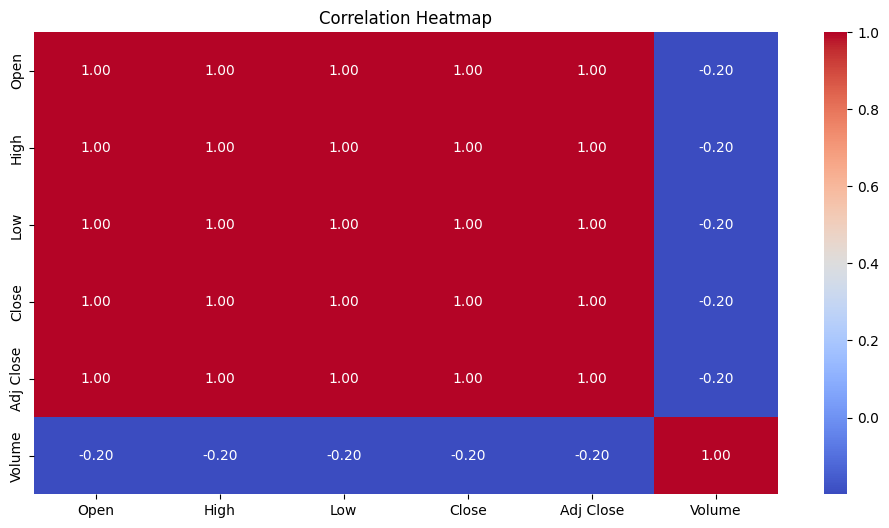

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index (optional but recommended)
df.set_index('Date', inplace=True)

# Select only numeric columns
df = df.select_dtypes(include='number')

# Create heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [8]:
quarterly = df.resample('QE').mean()
print(quarterly.head())

                Open      High       Low     Close  Adj Close        Volume
Date                                                                       
1980-12-31  0.136075  0.136461  0.135903  0.135903   0.106075  1.034501e+08
1981-03-31  0.123749  0.124109  0.123335  0.123335   0.096265  2.631169e+07
1981-06-30  0.129792  0.130226  0.129473  0.129473   0.101057  3.298276e+07
1981-09-30  0.097116  0.097412  0.096723  0.096723   0.075495  3.062080e+07
1981-12-31  0.085667  0.086103  0.085449  0.085449   0.066695  3.949960e+07


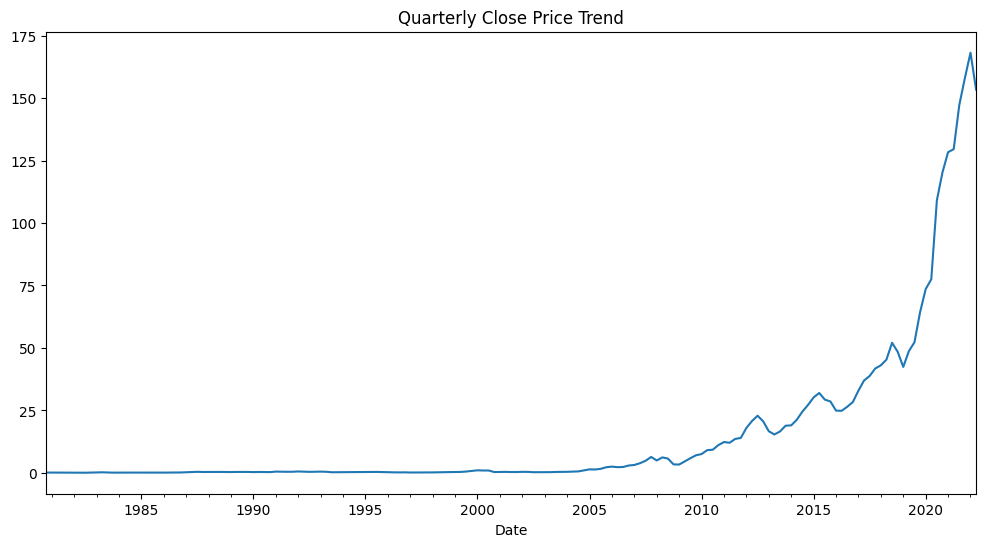

In [9]:
quarterly['Close'].plot(figsize=(12,6), title="Quarterly Close Price Trend")
plt.show()

In [10]:
events = {
    "Macintosh Launch": "1984-01-24",
    "Jobs Ousted": "1985-09-16",
    "Jobs Returns": "1997-09-16",
    "iTunes Launch": "2001-01-09",
    "iPod Launch": "2001-10-23",
    "iPhone Launch": "2007-06-29",
    "Tim Cook CEO": "2011-08-24",
    "iPhone 6 & Watch": "2014-09-01",
    "1 Trillion Market Cap": "2018-08-02",
    "COVID Pop": "2021-03-09"
}

# Convert to datetime
events = {k: pd.to_datetime(v) for k, v in events.items()}

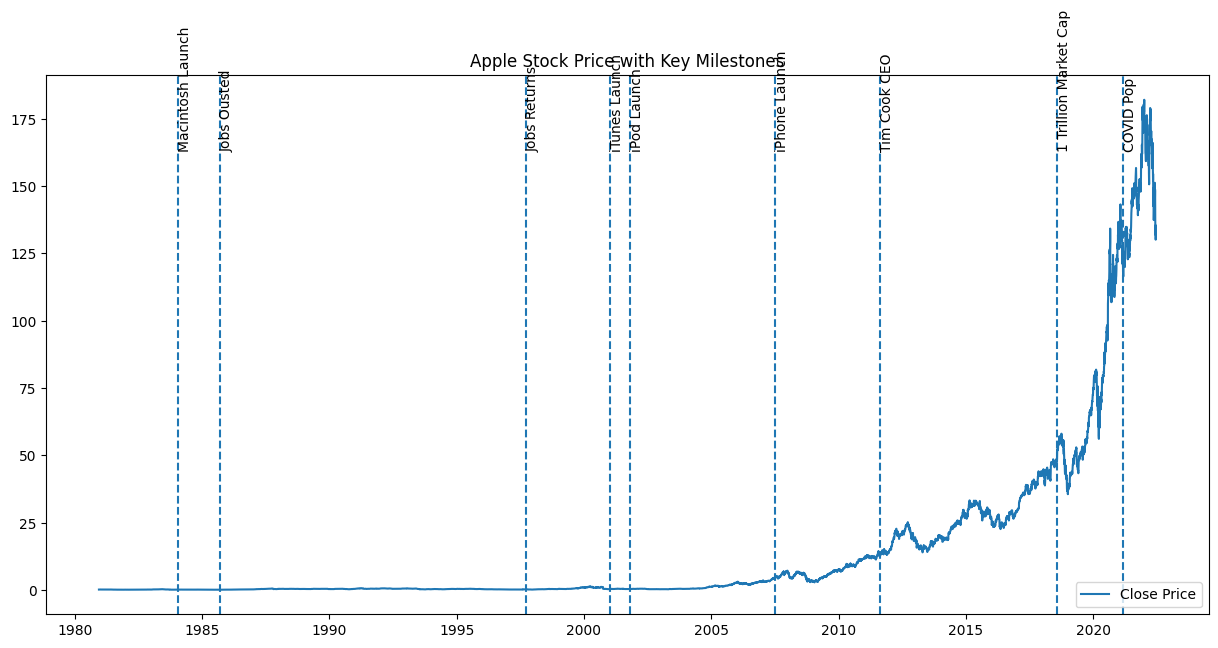

In [11]:
plt.figure(figsize=(15,7))

# Plot stock price
plt.plot(df['Close'], label='Close Price')

# Add vertical lines for events
for event, date in events.items():
    if date in df.index:
        plt.axvline(x=date, linestyle='--')
        plt.text(date, df['Close'].max()*0.9, event, rotation=90)

plt.title("Apple Stock Price with Key Milestones")
plt.legend()
plt.show()

In [12]:
analysis = []

for event, date in events.items():
    if date in df.index:
        before = df.loc[date - pd.Timedelta(days=15):date]['Close'].mean()
        after = df.loc[date:date + pd.Timedelta(days=15)]['Close'].mean()
        
        change = ((after - before) / before) * 100
        
        analysis.append([event, before, after, change])

result = pd.DataFrame(analysis, columns=["Event", "Before Avg", "After Avg", "% Change"])
print(result)

                   Event  Before Avg   After Avg   % Change
0       Macintosh Launch    0.125000    0.112398 -10.081800
1            Jobs Ousted    0.068192    0.071885   5.416434
2           Jobs Returns    0.197798    0.194778  -1.527160
3          iTunes Launch    0.281473    0.326806  16.105465
4            iPod Launch    0.314316    0.332039   5.638627
5          iPhone Launch    4.353958    4.651393   6.831362
6           Tim Cook CEO   13.276845   13.640130   2.736228
7  1 Trillion Market Cap   48.488125   52.395417   8.058245
8              COVID Pop  122.785833  122.076666  -0.577564


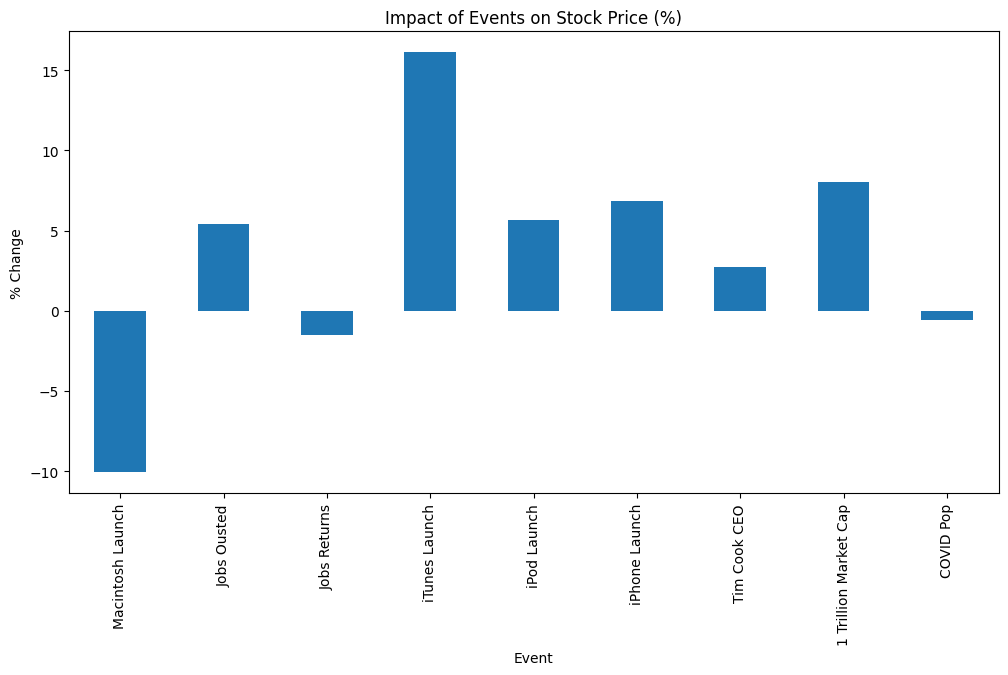

In [13]:
result.set_index("Event")["% Change"].plot(kind='bar', figsize=(12,6))
plt.title("Impact of Events on Stock Price (%)")
plt.ylabel("% Change")
plt.show()